# Vienna Weather Patch Batch Extractor (WFS + WMTS)

This notebook generates **training-ready static patches** per station for your Deep Learning pipeline.

## Outputs per station
- `static_patches/<station_id>_static.npy` — multi-channel tensor `(C, 64, 64)`
- `static_patches/<station_id>_static.meta.json` — bbox/CRS/channel metadata
- `static_patches/<station_id>_preview_rgb.png` — orthophoto preview
- `static_patches/<station_id>_preview_overlay.png` — orthophoto + vector-mask overlay preview

## Why WMTS for imagery
WMS often returns styled/blank images or server exceptions. **WMTS** is tile-based and reliable for orthophotos.

You can still use WMS for other rasters if required, but this notebook defaults to **basemap.at WMTS orthophoto**.


In [38]:
# Core deps
# !pip install geopandas rasterio shapely pyproj requests pillow lxml

import os, io, re, json, math, time, tempfile
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import requests

import geopandas as gpd
from shapely.geometry import Point, box

import rasterio
from rasterio.transform import from_origin
from rasterio.features import rasterize

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import matplotlib.pyplot as plt

OSM_COURTESY_DELAY_S = 0.2


## Pixel-Perfect Alignment (WMTS base + WFS masks)

To avoid misalignment between the **WMTS orthophoto (google3857 / EPSG:3857)** and **WFS vector overlays**, this notebook enforces:

- **Single CRS for patch grid:** `EPSG:3857`
- **Single grid definition:** bbox in EPSG:3857 + `rasterio.transform.from_bounds(...)` to create the exact 64×64 affine transform
- **Vector rasterization uses the exact same (bbox, CRS, transform, shape)** as the WMTS RGB patch

This guarantees that preview overlays match the actual training tensor channels.


In [39]:

from rasterio.transform import from_bounds

def patch_transform_from_bbox(bbox_3857, patch_pixels: int):
    """Affine transform for a bbox on a patch_pixels×patch_pixels grid."""
    minx, miny, maxx, maxy = bbox_3857
    return from_bounds(minx, miny, maxx, maxy, patch_pixels, patch_pixels)

def rasterize_mask_on_patch_grid(gdf, bbox_3857, patch_pixels: int, burn_value: int = 1):
    """Rasterize GeoDataFrame geometries onto the exact WMTS patch grid."""
    import numpy as np
    from rasterio.features import rasterize

    if gdf is None or len(gdf) == 0:
        return np.zeros((patch_pixels, patch_pixels), dtype=np.uint8)

    transform = patch_transform_from_bbox(bbox_3857, patch_pixels)
    shapes = [(geom, burn_value) for geom in gdf.geometry if geom is not None and not geom.is_empty]
    if not shapes:
        return np.zeros((patch_pixels, patch_pixels), dtype=np.uint8)

    mask = rasterize(
        shapes=shapes,
        out_shape=(patch_pixels, patch_pixels),
        transform=transform,
        fill=0,
        dtype=np.uint8,
        all_touched=False,
    )
    return mask


In [40]:
# ---------- Configuration ----------

@dataclass(frozen=True)
class PatchSpec:
    patch_pixels: int = 64
    patch_meters: float = 1000.0              # 1km x 1km
    crs_input: str = "EPSG:4326"              # stations lon/lat
    crs_metric: str = "EPSG:32633"            # UTM 33N (for vector rasterization / metadata)
    crs_wmts: str = "EPSG:3857"               # WebMercator (WMTS native)

@dataclass(frozen=True)
class WFSConfig:
    url: str = "https://data.wien.gv.at/daten/geo"
    version: str = "1.1.0"
    timeout_s: int = 60

@dataclass(frozen=True)
class WMTSConfig:
    capabilities_url: str = "https://mapsneu.wien.gv.at/basemapneu/1.0.0/WMTSCapabilities.xml"
    layer: str = "bmaporthofoto30cm"          # orthophoto
    tilematrixset: str = "google3857"         # common WMTS matrix set
    timeout_s: int = 60

SPEC = PatchSpec(patch_pixels=256, patch_meters=5000.0)
WFS = WFSConfig()
WMTS = WMTSConfig()

# Station CSV location (as provided in this chat workspace)
STATIONS_CSV = "./stations_vienna.csv"
OUT_DIR = "./static_patches"
os.makedirs(OUT_DIR, exist_ok=True)


In [41]:
# ---------- CRS helpers ----------

def lonlat_to_crs(lon: float, lat: float, src: str, dst: str) -> Tuple[float, float]:
    gs = gpd.GeoSeries([Point(lon, lat)], crs=src).to_crs(dst)
    p = gs.iloc[0]
    return float(p.x), float(p.y)

def metric_bbox_around(x: float, y: float, half_size_m: float) -> Tuple[float, float, float, float]:
    return (x - half_size_m, y - half_size_m, x + half_size_m, y + half_size_m)

def patch_transform_from_bbox(bbox: Tuple[float,float,float,float], spec: PatchSpec):
    minx, miny, maxx, maxy = bbox
    res = spec.patch_meters / spec.patch_pixels
    return from_origin(minx, maxy, res, res)


## 1) WMTS orthophoto patch extraction (reliable)

We parse the WMTS capabilities to get the tile URL template, then fetch and stitch the tiles covering the patch bbox.


In [42]:
# ---------- WMTS parsing ----------

from lxml import etree

def parse_wmts_resource_url(capabilities_xml: str, layer: str, fmt_contains: str = "jpeg") -> str:
    """Return ResourceURL template for a WMTS layer (e.g. .../{TileMatrix}/{TileRow}/{TileCol}.jpg)."""
    ns = {
        "wmts": "http://www.opengis.net/wmts/1.0",
        "ows": "http://www.opengis.net/ows/1.1",
        "xlink": "http://www.w3.org/1999/xlink",
    }

    root = etree.fromstring(capabilities_xml.encode("utf-8"))
    layers = root.findall(".//wmts:Layer", namespaces=ns)

    for lyr in layers:
        ident = lyr.find("ows:Identifier", namespaces=ns)
        if ident is None or ident.text != layer:
            continue

        # Prefer ResourceURL templates (fast, simple)
        for ru in lyr.findall("wmts:ResourceURL", namespaces=ns):
            template = ru.get("template")
            fmt = (ru.get("format") or "").lower()
            if template and fmt_contains in fmt:
                return template

        # Fallback: KVP GetTile endpoint
        # (Less convenient; not implemented here.)

    raise ValueError(f"Could not find ResourceURL template for layer={layer}")


def get_wmts_template(cfg: WMTSConfig) -> str:
    r = requests.get(cfg.capabilities_url, timeout=cfg.timeout_s)
    r.raise_for_status()
    xml = r.text
    time.sleep(OSM_COURTESY_DELAY_S) 
    return parse_wmts_resource_url(xml, layer=cfg.layer, fmt_contains="jpeg")

WMTS_TEMPLATE = get_wmts_template(WMTS)
print("WMTS template:", WMTS_TEMPLATE[:120] + "...")


WMTS template: https://mapsneu.wien.gv.at/basemap/bmaporthofoto30cm/{Style}/{TileMatrixSet}/{TileMatrix}/{TileRow}/{TileCol}.jpeg...


In [43]:
# ---------- WMTS tile math (google3857) ----------

# WebMercator constants
R = 6378137.0
ORIGIN_SHIFT = 2 * math.pi * R / 2.0
TILE_SIZE = 256


def resolution_m_per_px(zoom: int) -> float:
    # initial resolution at equator
    initial = 2 * math.pi * R / TILE_SIZE
    return initial / (2 ** zoom)


def meters_to_tile(x: float, y: float, zoom: int) -> Tuple[int, int]:
    # Convert meters to pixels then to tile
    res = resolution_m_per_px(zoom)
    px = int((x + ORIGIN_SHIFT) / res)
    py = int((ORIGIN_SHIFT - y) / res)
    tx = px // TILE_SIZE
    ty = py // TILE_SIZE
    return tx, ty


def tile_bounds_m(tx: int, ty: int, zoom: int) -> Tuple[float, float, float, float]:
    res = resolution_m_per_px(zoom)
    minx = tx * TILE_SIZE * res - ORIGIN_SHIFT
    maxx = (tx + 1) * TILE_SIZE * res - ORIGIN_SHIFT
    maxy = ORIGIN_SHIFT - ty * TILE_SIZE * res
    miny = ORIGIN_SHIFT - (ty + 1) * TILE_SIZE * res
    return (minx, miny, maxx, maxy)


def fetch_wmts_tile(template: str, layer: str, tilematrixset: str, zoom: int, tx: int, ty: int, timeout_s: int = 60) -> Image.Image:
    # ResourceURL template usually contains {Style}, {TileMatrixSet}, {TileMatrix}, {TileRow}, {TileCol}
    url = template.format(
        Style="normal",
        TileMatrixSet=tilematrixset,
        TileMatrix=str(zoom),
        TileRow=str(ty),
        TileCol=str(tx),
    )
    r = requests.get(url, timeout=timeout_s)
    r.raise_for_status()
    time.sleep(OSM_COURTESY_DELAY_S) 
    return Image.open(io.BytesIO(r.content)).convert("RGB")


def wmts_patch_rgb(lon: float, lat: float, spec: PatchSpec, wmts: WMTSConfig, zoom: Optional[int] = None) -> np.ndarray:
    """Return RGB patch as (3,H,W) float32 in 0..255."""
    # Decide zoom if not set: target ~15.6 m/px. Zoom 14 is ~9.55m/px, zoom 13 is ~19.1m/px.
    if zoom is None:
        target = spec.patch_meters / spec.patch_pixels
        zoom = 14 if abs(resolution_m_per_px(14) - target) < abs(resolution_m_per_px(13) - target) else 13

    # Center in EPSG:3857
    x, y = lonlat_to_crs(lon, lat, spec.crs_input, spec.crs_wmts)
    half = spec.patch_meters / 2.0
    bbox = (x - half, y - half, x + half, y + half)  # in meters (3857)

    minx, miny, maxx, maxy = bbox
    tx0, ty0 = meters_to_tile(minx, maxy, zoom)  # top-left tile
    tx1, ty1 = meters_to_tile(maxx, miny, zoom)  # bottom-right tile

    # Ensure correct ranges
    tx0, tx1 = sorted([tx0, tx1])
    ty0, ty1 = sorted([ty0, ty1])

    cols = tx1 - tx0 + 1
    rows = ty1 - ty0 + 1

    canvas = Image.new("RGB", (cols * TILE_SIZE, rows * TILE_SIZE))

    for r_i, ty in enumerate(range(ty0, ty1 + 1)):
        for c_i, tx in enumerate(range(tx0, tx1 + 1)):
            tile = fetch_wmts_tile(WMTS_TEMPLATE, wmts.layer, wmts.tilematrixset, zoom, tx, ty, timeout_s=wmts.timeout_s)
            canvas.paste(tile, (c_i * TILE_SIZE, r_i * TILE_SIZE))

    # Crop canvas to exact bbox in pixel coordinates
    res = resolution_m_per_px(zoom)
    # top-left of canvas in meters
    canvas_minx, canvas_miny, canvas_maxx, canvas_maxy = tile_bounds_m(tx0, ty0, zoom)

    # Pixel offsets within canvas
    left_px = int(round((minx - canvas_minx) / res))
    right_px = int(round((maxx - canvas_minx) / res))
    top_px = int(round((canvas_maxy - maxy) / res))
    bottom_px = int(round((canvas_maxy - miny) / res))

    crop = canvas.crop((left_px, top_px, right_px, bottom_px))

    # Resize to training resolution
    crop = crop.resize((spec.patch_pixels, spec.patch_pixels), resample=Image.BILINEAR)

    arr = np.asarray(crop).astype(np.float32)  # (H,W,3)
    arr = np.transpose(arr, (2, 0, 1))         # (3,H,W)
    return arr


## 2) WFS vector fetch + rasterize masks

Vienna's endpoint behaves like GeoServer. We validate typenames first, then fetch features and rasterize them onto the same 64×64 grid.


In [44]:
# ---------- WFS capabilities + typename validation ----------

def list_wfs_typenames(wfs_url: str, timeout_s: int = 60) -> set:
    r = requests.get(wfs_url, params={"service":"WFS","request":"GetCapabilities"}, timeout=timeout_s)
    r.raise_for_status()
    # GeoServer capabilities: many <Name> entries; filter for names containing ':' (workspace)
    names = set(re.findall(r"<Name>([^<]+)</Name>", r.text))
    return names

AVAILABLE_TYPENAMES = list_wfs_typenames(WFS.url, timeout_s=WFS.timeout_s)
print("Found typenames (sample):")
for n in sorted([x for x in AVAILABLE_TYPENAMES if x.startswith('ogdwien:')])[:30]:
    print("  ", n)


Found typenames (sample):
   ogdwien:ABWARMEPOTOGD
   ogdwien:ABWASSERWAERMEOGD
   ogdwien:ADRESSENOGD
   ogdwien:ADVENTMARKTOGD
   ogdwien:AKUSTISCHEAMPELOGD
   ogdwien:ALLESGURGELTOGD
   ogdwien:ALTSTOFFSAMMLUNGOGD
   ogdwien:AMBULANZOGD
   ogdwien:AMPELOGD
   ogdwien:AMTOGD
   ogdwien:ANLAGENLEISTUNGOGD
   ogdwien:APOTHEKEOGD
   ogdwien:ARCHAEODATIERUNGOGD
   ogdwien:ARCHAEOSDLGOGD
   ogdwien:ARCHAEOSTRASSENOGD
   ogdwien:ARZTOGD
   ogdwien:ASFINAGKNOTENOGD
   ogdwien:ASFINAGSPEEDOGD
   ogdwien:ASFINAGSTRASSEOGD
   ogdwien:AUFZUGOGD
   ogdwien:AUSBLICKSPUNKTOGD
   ogdwien:BADESTELLENOGD
   ogdwien:BANKAUSTRIAOGD
   ogdwien:BASEMAPVERDOGD
   ogdwien:BAUBLOCKOGD
   ogdwien:BAUMKATOGD
   ogdwien:BAUSTELLENLINOGD
   ogdwien:BAUSTELLENPKTOGD
   ogdwien:BEFUNDARCHAEOOGD
   ogdwien:BEGEGNUNGSZONEOGD


In [ ]:
# ---------- Choose relevant vector layers (adjust as needed) ----------

# These are KNOWN to exist in the capabilities you shared earlier in this chat.
# If any are missing in your live server, the validation cell will show it.

VECTOR_LAYERS = {
    "roads_graph": "ogdwien:STRASSENGRAPHOGD",   # lines
    "trees": "ogdwien:BAUMKATOGD",               # points (tree locations)
    "public_green": "ogdwien:OEFFGRUENPKTGOGD", # points (public green)
    "Abwaerme": "ogdwien:ABWARMEPOTOGD", # points (public green)
    "abwasser": "ogdwien:ABWASSERWAERMEOGD", # points (public green)
}

missing = [tn for tn in VECTOR_LAYERS.values() if tn not in AVAILABLE_TYPENAMES]
if missing:
    print("WARNING: Some typenames missing on server:", missing)
else:
    print("All selected typenames are available.")


All selected typenames are available.


In [46]:
# ---------- WFS GetFeature (GML-safe) ----------

def _is_xml(b: bytes) -> bool:
    head = b[:200].lower()
    return b"<?xml" in head or b"<wfs:featurecollection" in head or b"<featurecollection" in head or b"<ows:exception" in head


def _extract_exception_text(b: bytes) -> str:
    txt = b.decode("utf-8", errors="replace")
    m = re.search(r"<ows:ExceptionText[^>]*>(.*?)</ows:ExceptionText>", txt, re.DOTALL | re.IGNORECASE)
    if m:
        return re.sub(r"\s+", " ", m.group(1)).strip()
    m = re.search(r"<ServiceException[^>]*>(.*?)</ServiceException>", txt, re.DOTALL | re.IGNORECASE)
    if m:
        return re.sub(r"\s+", " ", m.group(1)).strip()
    preview = re.sub(r"<[^>]+>", " ", txt)
    preview = re.sub(r"\s+", " ", preview).strip()
    return preview[:400]


def fetch_wfs_gdf(typename: str, bbox_utm: Tuple[float,float,float,float], spec: PatchSpec, wfs: WFSConfig, debug_dir: str = "./_wfs_debug") -> gpd.GeoDataFrame:
    os.makedirs(debug_dir, exist_ok=True)
    minx, miny, maxx, maxy = bbox_utm

    params = {
        "SERVICE": "WFS",
        "REQUEST": "GetFeature",
        "VERSION": "1.1.0",
        "TYPENAME": typename,
        "SRSNAME": spec.crs_metric,
        "BBOX": f"{minx},{miny},{maxx},{maxy},{spec.crs_metric}",
        # Force GML; GeoJSON support is inconsistent on WFS 1.1.0
        "OUTPUTFORMAT": "text/xml; subtype=gml/3.1.1",
    }

    r = requests.get(wfs.url, params=params, timeout=wfs.timeout_s)
    time.sleep(OSM_COURTESY_DELAY_S) 
    if r.status_code != 200:
        path = os.path.join(debug_dir, f"http_{r.status_code}_{typename.replace(':','_')}.bin")
        with open(path, "wb") as f:
            f.write(r.content)
        raise RuntimeError(f"WFS HTTP {r.status_code} for {typename}. Saved: {path}")

    body = r.content
    if _is_xml(body) and (b"Exception" in body[:2000] or b"ServiceException" in body[:2000]):
        path = os.path.join(debug_dir, f"exception_{typename.replace(':','_')}.xml")
        with open(path, "wb") as f:
            f.write(body)
        raise RuntimeError(f"WFS OWS Exception for {typename}. Saved: {path}. Message: {_extract_exception_text(body)}")

    # read GML via GeoPandas/Fiona -> temp file
    with tempfile.NamedTemporaryFile(suffix=".gml", delete=False) as tmp:
        tmp.write(body)
        tmp_path = tmp.name

    try:
        gdf = gpd.read_file(tmp_path)
    finally:
        try:
            os.remove(tmp_path)
        except OSError:
            pass

    if gdf.empty:
        return gpd.GeoDataFrame(geometry=[], crs=spec.crs_metric)

    # Ensure CRS
    if gdf.crs is None:
        gdf = gdf.set_crs(spec.crs_metric)
    else:
        gdf = gdf.to_crs(spec.crs_metric)

    # Clip
    patch_poly = box(minx, miny, maxx, maxy)
    try:
        gdf = gdf.clip(patch_poly)
    except Exception:
        gdf = gdf[gdf.intersects(patch_poly)]

    return gdf


def rasterize_mask(gdf: gpd.GeoDataFrame, bbox_utm: Tuple[float,float,float,float], spec: PatchSpec, burn_value: int = 1) -> np.ndarray:
    if gdf.empty:
        return np.zeros((spec.patch_pixels, spec.patch_pixels), dtype=np.uint8)

    transform = patch_transform_from_bbox(bbox_utm, spec)
    shapes = [(geom, burn_value) for geom in gdf.geometry if geom is not None and not geom.is_empty]
    if not shapes:
        return np.zeros((spec.patch_pixels, spec.patch_pixels), dtype=np.uint8)

    return rasterize(
        shapes=shapes,
        out_shape=(spec.patch_pixels, spec.patch_pixels),
        transform=transform,
        fill=0,
        dtype=np.uint8,
        all_touched=False,
    )


## 3) Preview image writers (auto-normalized)

These functions prevent the "all black" previews caused by range/scale issues and also produce overlay previews.


In [47]:
# ---------- Preview helpers ----------

def to_uint8_rgb(rgb_chw: np.ndarray) -> np.ndarray:
    x = rgb_chw.astype(np.float32)
    if np.nanmax(x) <= 1e-6:
        return np.zeros((x.shape[1], x.shape[2], 3), dtype=np.uint8)

    # 0..1 -> 0..255
    if np.nanmax(x) <= 1.0 + 1e-3:
        x = x * 255.0

    # Percentile scaling if range is huge
    if np.nanmax(x) > 255.0:
        lo = np.nanpercentile(x, 2)
        hi = np.nanpercentile(x, 98)
        if hi > lo:
            x = (x - lo) / (hi - lo) * 255.0
        else:
            x = np.zeros_like(x)

    x = np.clip(x, 0, 255).astype(np.uint8)
    return np.transpose(x, (1, 2, 0))


def save_rgb_preview(rgb_chw: np.ndarray, out_path: str) -> None:
    Image.fromarray(to_uint8_rgb(rgb_chw), mode="RGB").save(out_path)


def save_overlay_preview(rgb_chw: np.ndarray, masks: Dict[str, np.ndarray], out_path: str, alpha: float = 0.35) -> None:
    base = to_uint8_rgb(rgb_chw).astype(np.float32)
    palette = [
        (255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0),
        (255, 0, 255), (0, 255, 255), (255, 128, 0), (128, 0, 255)
    ]
    out = base.copy()

    for i, (name, m) in enumerate(masks.items()):
        color = np.array(palette[i % len(palette)], dtype=np.float32)
        mm = m.astype(np.float32)
        if mm.max() > 1.0:
            mm = (mm > 0).astype(np.float32)
        mask3 = mm[..., None]
        out = out * (1 - alpha * mask3) + color[None, None, :] * (alpha * mask3)

    out = np.clip(out, 0, 255).astype(np.uint8)
    Image.fromarray(out, mode="RGB").save(out_path)


## 4) Batch extractor

For each station:
- fetch orthophoto RGB via WMTS
- build UTM bbox and fetch vectors via WFS
- rasterize vector masks to 64×64 and stack channels
- save NPY + meta + PNG previews


In [48]:
def extract_station_patch(station_id: str, lon: float, lat: float, spec: PatchSpec) -> Tuple[np.ndarray, dict, np.ndarray, Dict[str,np.ndarray]]:
    # 1) Orthophoto RGB from WMTS (EPSG:3857 internally)
    rgb = wmts_patch_rgb(lon, lat, spec, WMTS)  # (3,64,64) float32 0..255

    # 2) UTM bbox for vector layers
    x_utm, y_utm = lonlat_to_crs(lon, lat, spec.crs_input, spec.crs_metric)
    half = spec.patch_meters / 2.0
    bbox_utm = metric_bbox_around(x_utm, y_utm, half)

    masks = {}
    for key, typename in VECTOR_LAYERS.items():
        gdf = fetch_wfs_gdf(typename, bbox_utm, spec, WFS)
        masks[key] = rasterize_mask(gdf, bbox_utm, spec)

    # 3) Stack channels: [RGB] + masks
    mask_channels = [m[None, ...].astype(np.float32) for m in masks.values()]
    patch = np.concatenate([rgb] + mask_channels, axis=0).astype(np.float32)  # (C,64,64)

    meta = {
        "station_id": station_id,
        "lon": lon, "lat": lat,
        "crs_metric": spec.crs_metric,
        "bbox_metric": bbox_utm,
        "patch_pixels": spec.patch_pixels,
        "patch_meters": spec.patch_meters,
        "channels": ["orthophoto_r", "orthophoto_g", "orthophoto_b"] + list(masks.keys()),
    }

    return patch, meta, rgb, masks


def batch_extract(stations_csv: str, out_dir: str, spec: PatchSpec,
                  lon_col: str = "Länge [°E]", lat_col: str = "Breite [°N]", id_col: str = "station_id",
                  limit: Optional[int] = None):
    os.makedirs(out_dir, exist_ok=True)
    df = pd.read_csv(stations_csv)

    # If your station id column differs, adjust here:
    if id_col not in df.columns:
        # common fallback in your CSV: "Stationsnummer" or similar
        for c in df.columns:
            if "id" in c.lower() or "station" in c.lower():
                id_col = c
                break

    failures = []

    if limit is not None:
        df = df.head(limit)

    for idx, row in df.iterrows():
        sid = str(row[id_col]) if id_col in row else str(idx)
        try:
            lon = float(row[lon_col])
            lat = float(row[lat_col])

            patch, meta, rgb, masks = extract_station_patch(sid, lon, lat, spec)

            # Save artifacts
            npy_path = os.path.join(out_dir, f"{sid}_static.npy")
            np.save(npy_path, patch)

            meta_path = os.path.join(out_dir, f"{sid}_static.meta.json")
            with open(meta_path, "w", encoding="utf-8") as f:
                json.dump(meta, f, ensure_ascii=False, indent=2)

            rgb_path = os.path.join(out_dir, f"{sid}_preview_rgb.png")
            save_rgb_preview(rgb, rgb_path)

            overlay_path = os.path.join(out_dir, f"{sid}_preview_overlay.png")
            save_overlay_preview(rgb, masks, overlay_path, alpha=0.35)

            # Quick diagnostic (first station only)
            if idx == 0:
                print("Sample station:", sid)
                print("Patch shape:", patch.shape)
                for c in range(min(patch.shape[0], 8)):
                    ch = patch[c]
                    print(f"ch{c}: min={ch.min():.3f}, max={ch.max():.3f}, mean={ch.mean():.3f}")

        except Exception as e:
            failures.append({"idx": int(idx), "station_id": sid, "error": str(e)})

    if failures:
        fail_path = os.path.join(out_dir, "_failures.json")
        with open(fail_path, "w", encoding="utf-8") as f:
            json.dump(failures, f, ensure_ascii=False, indent=2)
        print(f"Completed with {len(failures)} failures. See {fail_path}")
    else:
        print("Completed without failures.")

# Run a small test batch first
batch_extract(STATIONS_CSV, OUT_DIR, SPEC, id_col="Stationsnummer" if True else "station_id", limit=3)


/tmp/ipykernel_54941/2641755554.py:26: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(to_uint8_rgb(rgb_chw), mode="RGB").save(out_path)
/tmp/ipykernel_54941/2641755554.py:46: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(out, mode="RGB").save(out_path)


Sample station: 105
Patch shape: (6, 256, 256)
ch0: min=14.000, max=236.000, mean=100.034
ch1: min=22.000, max=238.000, mean=99.051
ch2: min=23.000, max=235.000, mean=90.727
ch3: min=0.000, max=1.000, mean=0.199
ch4: min=0.000, max=1.000, mean=0.164
ch5: min=0.000, max=1.000, mean=0.008


/tmp/ipykernel_54941/2641755554.py:26: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(to_uint8_rgb(rgb_chw), mode="RGB").save(out_path)
/tmp/ipykernel_54941/2641755554.py:46: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(out, mode="RGB").save(out_path)


Completed without failures.


/tmp/ipykernel_54941/2641755554.py:26: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(to_uint8_rgb(rgb_chw), mode="RGB").save(out_path)
/tmp/ipykernel_54941/2641755554.py:46: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(out, mode="RGB").save(out_path)


Found previews: 3


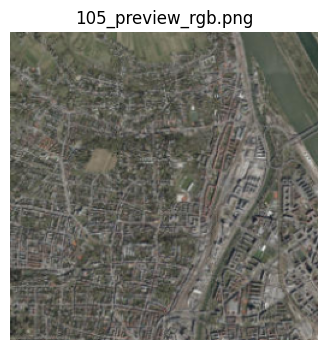

In [49]:
# ---------- Visual sanity check for one output ----------

# Pick a station id from the first few that succeeded
import glob
rgb_files = sorted(glob.glob(os.path.join(OUT_DIR, "*_preview_rgb.png")))
print("Found previews:", len(rgb_files))

if rgb_files:
    img = Image.open(rgb_files[0]).convert("RGB")
    plt.figure(figsize=(4,4))
    plt.title(os.path.basename(rgb_files[0]))
    plt.imshow(img)
    plt.axis("off")
    plt.show()



## Legend for Preview Images

The preview images generated by this notebook follow a **fixed semantic color legend** so that visual inspection is consistent across all stations.

### RGB Base Layer
- **Orthophoto RGB**: True-color aerial imagery (basemap.at / Vienna OGD)

### Overlay Mask Colors

| Color | Layer | Description |
|------|-------|-------------|
| Red | Roads | Street graph / traffic infrastructure |
| Green | Green Areas | Parks, public green spaces |
| Blue | Water | Rivers, lakes, channels |
| Yellow | Buildings | Building footprints |
| Purple | Trees | Individual tree locations / density |
| Orange | Land Use | Zoning / land-use areas |

> Overlay transparency is controlled via the `alpha` parameter (default: 0.35).
> Black areas indicate no data or outside coverage.


In [50]:

from PIL import Image, ImageDraw

def save_legend_image(out_path="preview_legend.png"):
    items = [
        ("Roads", (255, 0, 0)),
        ("Green Areas", (0, 255, 0)),
        ("Water", (0, 0, 255)),
        ("Buildings", (255, 255, 0)),
        ("Trees", (128, 0, 255)),
        ("Land Use", (255, 128, 0)),
    ]

    width, height = 400, 40 * len(items) + 20
    img = Image.new("RGB", (width, height), (255, 255, 255))
    d = ImageDraw.Draw(img)

    y = 10
    for label, color in items:
        d.rectangle([10, y, 30, y + 20], fill=color)
        d.text((40, y), label, fill=(0, 0, 0))
        y += 40

    img.save(out_path)
    print(f"Legend saved to {out_path}")

save_legend_image()


Legend saved to preview_legend.png



## Additional Base Layer: OpenStreetMap (OSM)

This notebook adds **OpenStreetMap raster tiles** as an optional base layer.

- Source: https://tile.openstreetmap.org/{z}/{x}/{y}.png
- CRS: EPSG:3857 (WebMercator)
- A custom User-Agent is required to avoid HTTP 403.


In [51]:

# ---------- OpenStreetMap WMTS-style layer ----------
import requests
import io
from PIL import Image
import numpy as np

OSM_TILE_TEMPLATE = "https://tile.openstreetmap.org/{z}/{x}/{y}.png"
OSM_HEADERS = {
    "User-Agent": "ResearchProject_FH_AI/1.0 (contact: student@fh-salzburg.ac.at)"
}

def fetch_osm_tile(z: int, x: int, y: int, timeout_s: int = 30) -> Image.Image:
    url = OSM_TILE_TEMPLATE.format(z=z, x=x, y=y)
    r = requests.get(url, headers=OSM_HEADERS, timeout=timeout_s)
    r.raise_for_status()
    return Image.open(io.BytesIO(r.content)).convert("RGB")

def wmts_patch_osm_rgb(lon: float, lat: float, spec: PatchSpec, zoom: int) -> np.ndarray:
    """Return OSM RGB patch as (3,H,W) aligned to EPSG:3857."""
    x, y = lonlat_to_crs(lon, lat, spec.crs_input, spec.crs_metric)
    half = spec.patch_meters / 2.0
    bbox = (x - half, y - half, x + half, y + half)

    minx, miny, maxx, maxy = bbox
    tx0, ty0 = meters_to_tile(minx, maxy, zoom)
    tx1, ty1 = meters_to_tile(maxx, miny, zoom)
    tx0, tx1 = sorted([tx0, tx1])
    ty0, ty1 = sorted([ty0, ty1])

    cols = tx1 - tx0 + 1
    rows = ty1 - ty0 + 1
    canvas = Image.new("RGB", (cols * TILE_SIZE, rows * TILE_SIZE))

    for r_i, ty in enumerate(range(ty0, ty1 + 1)):
        for c_i, tx in enumerate(range(tx0, tx1 + 1)):
            tile = fetch_osm_tile(zoom, tx, ty)
            canvas.paste(tile, (c_i * TILE_SIZE, r_i * TILE_SIZE))

    res = resolution_m_per_px(zoom)
    canvas_minx, canvas_miny, canvas_maxx, canvas_maxy = tile_bounds_m(tx0, ty0, zoom)

    left_px = int(round((minx - canvas_minx) / res))
    right_px = int(round((maxx - canvas_minx) / res))
    top_px = int(round((canvas_maxy - maxy) / res))
    bottom_px = int(round((canvas_maxy - miny) / res))

    crop = canvas.crop((left_px, top_px, right_px, bottom_px))
    crop = crop.resize((spec.patch_pixels, spec.patch_pixels), resample=Image.BILINEAR)

    arr = np.asarray(crop).astype(np.float32)
    return np.transpose(arr, (2, 0, 1))



## Batch Extraction: Include OSM in `.npy` + Additional OSM Overlay Preview

This section updates the batch extractor to:

1. Fetch and stack **OSM RGB** into the training tensor (`*.npy`) in addition to **Orthophoto RGB**.
2. Save **two base previews** per station:
   - `*_preview_ortho_rgb.png` and `*_preview_ortho_overlay.png`
   - `*_preview_osm_rgb.png` and `*_preview_osm_overlay.png`
3. The same vector masks are overlaid on both base layers.

Channel layout:

- `[0..2]` Orthophoto RGB
- `[3..5]` OSM RGB
- `[6..]` Vector masks (WFS rasterized)


In [52]:

# ---------- Updated batch extractor: add OSM into tensor + OSM overlay previews ----------
import os
import json
import numpy as np

def extract_all_station_patches_with_osm(
    stations_csv: str,
    out_dir: str,
    spec: PatchSpec,
    wmts_ortho: WMTSConfig,
    osm_zoom: int,
    wfs_layers: dict,
    lon_col: str = "Länge [°E]",
    lat_col: str = "Breite [°N]",
    sleep_s: float = 0.0,
):
    """Batch extraction producing .npy + meta + ortho/osm previews with overlays."""
    import pandas as pd
    import time

    os.makedirs(out_dir, exist_ok=True)
    stations = pd.read_csv(stations_csv)

    failures = []

    for idx, row in stations.iterrows():
        sid = safe_station_id(row) if "safe_station_id" in globals() else str(idx)
        try:
            lon = float(row[lon_col])
            lat = float(row[lat_col])

            # ----- Base layers (both aligned in EPSG:3857) -----
            ortho_rgb = wmts_patch_rgb(lon, lat, spec, wmts_ortho)           # (3,H,W) 0..255
            osm_rgb   = wmts_patch_osm_rgb(lon, lat, spec, zoom=osm_zoom)    # (3,H,W) 0..255

            # ----- Shared bbox in EPSG:3857 for rasterization -----
            x, y = lonlat_to_crs(lon, lat, spec.crs_input, spec.crs_metric)
            half = spec.patch_meters / 2.0
            bbox = (x - half, y - half, x + half, y + half)  # EPSG:3857

            # ----- Vector masks (rasterize on the exact patch grid) -----
            mask_channels = []
            mask_dict_for_overlay = {}

            for name, cfg in wfs_layers.items():
                gdf = fetch_wfs_features(bbox, spec, cfg)  # should be in spec.crs_metric (EPSG:3857)
                try:
                    if gdf is not None and len(gdf) and gdf.crs and str(gdf.crs) != str(spec.crs_metric):
                        gdf = gdf.to_crs(spec.crs_metric)
                except Exception:
                    pass

                mask = rasterize_mask_on_patch_grid(gdf, bbox, spec.patch_pixels)  # (H,W) uint8
                mask_channels.append(mask.astype(np.float32)[None, ...])           # (1,H,W)
                mask_dict_for_overlay[name] = mask.astype(np.float32)

            # ----- Stack tensor for training -----
            patch = np.concatenate(
                [ortho_rgb.astype(np.float32), osm_rgb.astype(np.float32)] + mask_channels,
                axis=0
            ).astype(np.float32)  # (C,H,W)

            # Save tensor
            npy_path = os.path.join(out_dir, f"{sid}_static.npy")
            np.save(npy_path, patch)

            # Save previews
            ortho_rgb_path = os.path.join(out_dir, f"{sid}_preview_ortho_rgb.png")
            save_rgb_preview(ortho_rgb, ortho_rgb_path)

            ortho_overlay_path = os.path.join(out_dir, f"{sid}_preview_ortho_overlay.png")
            save_overlay_preview(ortho_rgb, mask_dict_for_overlay, ortho_overlay_path, alpha=0.35)

            osm_rgb_path = os.path.join(out_dir, f"{sid}_preview_osm_rgb.png")
            save_rgb_preview(osm_rgb, osm_rgb_path)

            osm_overlay_path = os.path.join(out_dir, f"{sid}_preview_osm_overlay.png")
            save_overlay_preview(osm_rgb, mask_dict_for_overlay, osm_overlay_path, alpha=0.35)

            # Save metadata
            meta = {
                "station_id": sid,
                "lon": lon,
                "lat": lat,
                "crs_patch": spec.crs_metric,
                "bbox_patch": bbox,
                "patch_pixels": spec.patch_pixels,
                "patch_meters": spec.patch_meters,
                "channel_layout": {
                    "orthophoto_rgb": [0, 1, 2],
                    "osm_rgb": [3, 4, 5],
                    "masks_start_index": 6,
                    "mask_names_in_order": list(wfs_layers.keys()),
                },
                "files": {
                    "npy": os.path.basename(npy_path),
                    "preview_ortho_rgb": os.path.basename(ortho_rgb_path),
                    "preview_ortho_overlay": os.path.basename(ortho_overlay_path),
                    "preview_osm_rgb": os.path.basename(osm_rgb_path),
                    "preview_osm_overlay": os.path.basename(osm_overlay_path),
                }
            }
            with open(os.path.join(out_dir, f"{sid}_static.meta.json"), "w", encoding="utf-8") as f:
                json.dump(meta, f, ensure_ascii=False, indent=2)

            if sleep_s:
                time.sleep(sleep_s)

        except Exception as e:
            failures.append({"idx": idx, "station_id": sid, "error": str(e)})

    if failures:
        fail_path = os.path.join(out_dir, "_failures.json")
        with open(fail_path, "w", encoding="utf-8") as f:
            json.dump(failures, f, ensure_ascii=False, indent=2)
        print(f"[WARN] Completed with {len(failures)} failures. See: {fail_path}")
    else:
        print("[OK] Completed without failures.")


Found previews: 3


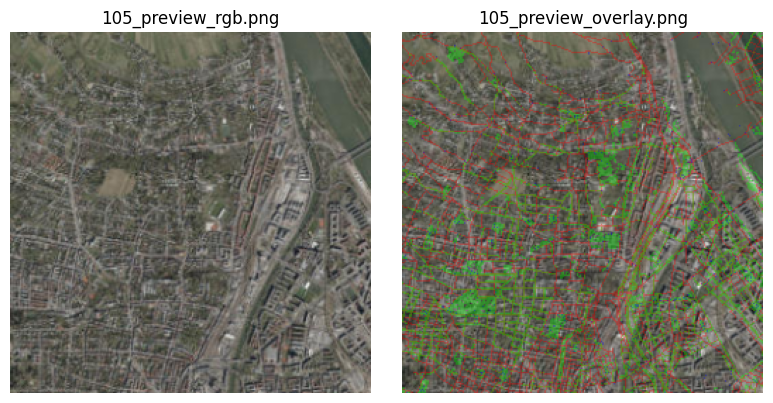

In [53]:
# ---------- Visual sanity check for one output ----------

# Pick a station id from the first few that succeeded
import glob
rgb_files = sorted(glob.glob(os.path.join(OUT_DIR, "*_preview_rgb.png")))
rgb_overlay_files = sorted(glob.glob(os.path.join(OUT_DIR, "*_preview_overlay.png")))
print("Found previews:", len(rgb_files))

if rgb_files:
    img = Image.open(rgb_files[0]).convert("RGB")
    over = Image.open(rgb_overlay_files[0]).convert("RGB")
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title(os.path.basename(rgb_files[0]))
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title(os.path.basename(rgb_overlay_files[0]))
    plt.imshow(over)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

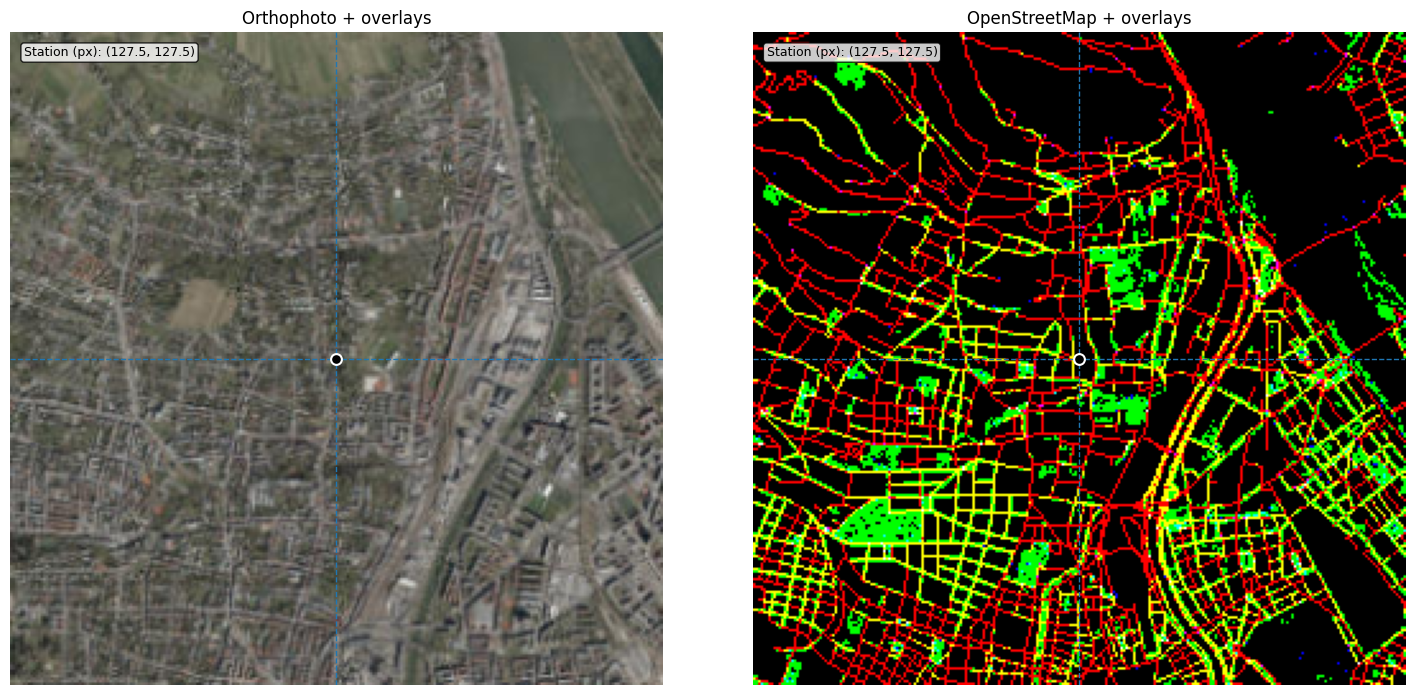

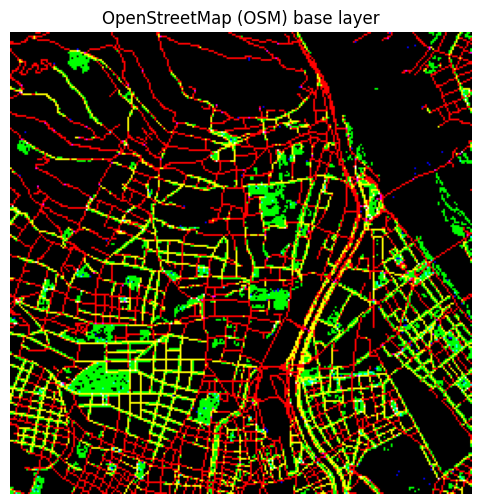

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PATCH_PATH = "static_patches/105_static.npy"

# Optional: provide lon/lat to show in the label
STATION_LON_LAT = None  # e.g., (16.3725, 48.2089)

# Optional: set overlay names from meta.json
CHANNEL_NAMES = None

OVERLAY_COLORS = [
    "red", "lime", "cyan", "yellow",
    "magenta", "orange", "blue", "white",
    "deepskyblue", "lawngreen", "gold", "violet"
]

def to_uint8_rgb(chw):
    x = chw.astype(np.float32)
    mx = np.nanmax(x)
    if mx <= 1.0 + 1e-6:
        x = x * 255.0
    if mx > 255.0:
        lo = np.nanpercentile(x, 2)
        hi = np.nanpercentile(x, 98)
        if hi > lo:
            x = (x - lo) / (hi - lo) * 255.0
        else:
            x = np.zeros_like(x)
    return np.clip(x, 0, 255).astype(np.uint8).transpose(1, 2, 0)

def default_channel_names(num_channels):
    base = ["orthophoto_R", "orthophoto_G", "orthophoto_B",
            "osm_R", "osm_G", "osm_B"]
    overlays = [f"overlay_ch{c}" for c in range(6, num_channels)]
    return (base + overlays)[:num_channels]

def draw_station_marker(ax, H, W, lonlat=None):
    # Center pixel (station)
    cx = (W - 1) / 2.0
    cy = (H - 1) / 2.0

    # Crosshair + dot
    ax.scatter([cx], [cy], s=60, marker="o", edgecolors="white", facecolors="black", linewidths=1.5, zorder=10)
    ax.axvline(cx, linewidth=1.0, linestyle="--", zorder=9)
    ax.axhline(cy, linewidth=1.0, linestyle="--", zorder=9)

    # Label
    if lonlat is None:
        txt = f"Station (px): ({cx:.1f}, {cy:.1f})"
    else:
        lon, lat = lonlat
        txt = f"Station (px): ({cx:.1f}, {cy:.1f})\nLon/Lat: ({lon:.6f}, {lat:.6f})"

    ax.text(
        5, 5, txt,
        va="top", ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8),
        zorder=11
    )

# Load patch
p = np.load(PATCH_PATH)
C, H, W = p.shape
assert C >= 6, f"Expected at least 6 channels (2 RGB base layers), got {C}"

if CHANNEL_NAMES is None:
    CHANNEL_NAMES = default_channel_names(C)
else:
    assert len(CHANNEL_NAMES) == C, f"CHANNEL_NAMES must have length {C}"

rgb_ortho = to_uint8_rgb(p[0:3])
rgb_osm   = to_uint8_rgb(p[3:6])
overlay_channels = list(range(6, C))

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

legend_handles, legend_labels = [], []

for ax, base_img, title in [
    (axes[0], rgb_ortho, "Orthophoto + overlays"),
    (axes[1], rgb_osm,   "OpenStreetMap + overlays"),
]:
    ax.imshow(base_img)

    # Overlays
    for i, ch in enumerate(overlay_channels):
        mask = p[ch]
        if np.nanmax(mask) <= 0:
            continue

        color = OVERLAY_COLORS[i % len(OVERLAY_COLORS)]
        label = CHANNEL_NAMES[ch] if ch < len(CHANNEL_NAMES) else f"ch{ch}"

        level = 0.5 if np.nanmax(mask) <= 1.0 + 1e-6 else float(np.nanpercentile(mask, 80))
        ax.contour(mask, levels=[level], colors=color, linewidths=1.5)

        if label not in legend_labels:
            legend_handles.append(Line2D([0], [0], color=color, lw=3))
            legend_labels.append(label)

    # Station marker (center)
    draw_station_marker(ax, H, W, lonlat=STATION_LON_LAT)

    ax.set_title(title)
    ax.axis("off")

# Shared legend
if legend_handles:
    fig.legend(
        handles=legend_handles,
        labels=legend_labels,
        loc="lower center",
        ncol=min(4, len(legend_labels)),
        frameon=True,
        bbox_to_anchor=(0.5, -0.02),
    )

plt.tight_layout()
plt.show()


In [63]:
import numpy as np

p = np.load("static_patches/105_static.npy")
C, H, W = p.shape

def looks_like_image_channel(ch):
    mx = np.nanmax(ch)
    mu = np.nanmean(ch)
    # heuristics: not all zeros, not a pure mask
    return (mx > 10) and (mu > 1e-3)

rgb_triplets = []
for i in range(C - 2):
    if looks_like_image_channel(p[i]) and looks_like_image_channel(p[i+1]) and looks_like_image_channel(p[i+2]):
        mxs = [np.nanmax(p[i+k]) for k in range(3)]
        mus = [np.nanmean(p[i+k]) for k in range(3)]
        rgb_triplets.append((i, mxs, mus))

print("Candidate RGB triplets (start index, max per channel, mean per channel):")
for t in rgb_triplets[:10]:
    print(t)


Candidate RGB triplets (start index, max per channel, mean per channel):
(0, [np.float32(236.0), np.float32(238.0), np.float32(235.0)], [np.float32(100.034134), np.float32(99.05072), np.float32(90.727234)])
